In [1]:
import sys

print(sys.executable)
print(sys.version)


/opt/homebrew/Caskroom/miniforge/base/envs/malaria_gpu/bin/python
3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]


This notebook performs exploratory data analysis on the RAVDESS dataset before
fine-tuning Wav2Vec2.

Objectives

• Analyze class balance
• Analyze duration distribution
• Verify sampling rates
• Inspect waveforms
• Inspect spectrograms
• Detect corrupted or silent files
• Verify preprocessing requirements (16 kHz mono)

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Audio libraries
import soundfile as sf
import librosa
import librosa.display

from typing import Dict, Tuple

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# ==========================================================
# Project Paths
# ==========================================================

# Current notebook folder
base_dir = Path.cwd()

# Notebook is inside:
# ser/notebooks/<this folder>
# so go back two levels to project root

PROJECT_ROOT = base_dir.parent.parent

DATASET_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "analysis"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("PROJECT ROOT :", PROJECT_ROOT)
print("DATASET_DIR  :", DATASET_DIR)
print("OUTPUT_DIR   :", OUTPUT_DIR)
print("="*60)


def savefig(name: str):
    plt.savefig(
        OUTPUT_DIR / name,
        dpi=300,
        bbox_inches="tight"
    )

PROJECT ROOT : /Users/devanshbansal/Desktop/ser
DATASET_DIR  : /Users/devanshbansal/Desktop/ser/outputs
OUTPUT_DIR   : /Users/devanshbansal/Desktop/ser/outputs/analysis


In [3]:
print("Current Working Directory")
print(Path.cwd())

print("\nPROJECT ROOT")
print(PROJECT_ROOT)

print("\nDATASET DIR")
print(DATASET_DIR)

print("\nEDA OUTPUT DIR")
print(OUTPUT_DIR)

print("\nFiles present inside outputs:\n")

for f in sorted(DATASET_DIR.iterdir()):
    print("•", f.name)

Current Working Directory
/Users/devanshbansal/Desktop/ser/notebooks/2Is the dataset balanced How long are the audio clips What do different emotions look like as waveforms What do their spectrograms and MFCCs look like

PROJECT ROOT
/Users/devanshbansal/Desktop/ser

DATASET DIR
/Users/devanshbansal/Desktop/ser/outputs

EDA OUTPUT DIR
/Users/devanshbansal/Desktop/ser/outputs/analysis

Files present inside outputs:

• analysis
• ravdess_dataset.csv
• ravdess_dataset.pkl


In [4]:
# Load the base dataset (created by previous notebook/script)
from pathlib import Path

# DATASET_DIR is a Path resolved in the first cell; fall back to cwd/outputs if missing
try:
    DATASET_DIR = Path(DATASET_DIR)
except NameError:
    DATASET_DIR = (Path.cwd() / '..' / '..' / 'outputs').resolve()

# Use pathlib consistently

df_path = DATASET_DIR / "ravdess_dataset.pkl"
if not df_path.exists():
    raise FileNotFoundError(f"Expected dataset pickle at {df_path} - create it first")

import pandas as pd

df = pd.read_pickle(df_path)
print("\nEmotion Classes:")
print(sorted(df["emotion"].unique()))

print("\nNumber of Classes:")
print(df["emotion"].nunique())
print(f"Loaded {len(df)} rows from {df_path}")

emotion_order = [
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]


Emotion Classes:
['angry', 'calm', 'disgust', 'fearful', 'happy', 'sad', 'surprised']

Number of Classes:
7
Loaded 1440 rows from /Users/devanshbansal/Desktop/ser/outputs/ravdess_dataset.pkl


## Audio Quality Verification

Before fine-tuning Wav2Vec2, each recording is validated to ensure it is suitable
for self-supervised speech representation learning.

Checks include:

- corrupted files
- silent recordings
- clipped signals
- abnormal duration
- sampling rate consistency

These issues can negatively affect Transformer-based speech models.

In [5]:
# Section 7 — Audio Quality & Wav2Vec2 Compatibility Checks
from typing import Dict
import numpy as np
import pandas as pd
import soundfile as sf

# Quality thresholds
SHORT_DURATION_SEC = 1.5
LONG_DURATION_SEC = 6.0
SILENCE_RMS_THRESHOLD = 0.001
CLIP_THRESHOLD = 0.99

def analyze_audio_quality(path: str) -> pd.Series:
    path = str(path)

    try:
        info = sf.info(path)
        duration = info.frames / info.samplerate if info.samplerate else np.nan
        sample_rate = info.samplerate
    except Exception as e:
        return pd.Series({
            "sample_rate": np.nan,
            "duration": np.nan,
            "peak_amplitude": np.nan,
            "rms_energy": np.nan,
            "corrupted": True,
            "silent": False,
            "clipped": False,
            "very_short": False,
            "very_long": False,
            "issue": f"corrupted: {e}",
        })

    try:
        y, _ = sf.read(path, dtype="float32", always_2d=False)

        if y.size == 0:
            raise ValueError("empty audio")

        if y.ndim > 1:
            y = np.mean(y, axis=1)

        peak_amplitude = float(np.max(np.abs(y)))
        rms_energy = float(np.sqrt(np.mean(np.square(y))))

        silent = (rms_energy <= SILENCE_RMS_THRESHOLD) or (peak_amplitude <= 0.01)
        clipped = (peak_amplitude >= CLIP_THRESHOLD) or (np.mean(np.abs(y) >= CLIP_THRESHOLD) > 0.001)
        very_short = duration < SHORT_DURATION_SEC
        very_long = duration > LONG_DURATION_SEC

        issues = []
        if silent:
            issues.append("silent")
        if clipped:
            issues.append("clipped")
        if very_short:
            issues.append("very_short")
        if very_long:
            issues.append("very_long")

        return pd.Series({
            "sample_rate": sample_rate,
            "duration": duration,
            "peak_amplitude": peak_amplitude,
            "rms_energy": rms_energy,
            "corrupted": False,
            "silent": silent,
            "clipped": clipped,
            "very_short": very_short,
            "very_long": very_long,
            "issue": ", ".join(issues) if issues else "clean",
        })

    except Exception as e:
        return pd.Series({
            "sample_rate": sample_rate,
            "duration": duration,
            "peak_amplitude": np.nan,
            "rms_energy": np.nan,
            "corrupted": True,
            "silent": False,
            "clipped": False,
            "very_short": False,
            "very_long": False,
            "issue": f"corrupted: {e}",
        })

quality_df = pd.concat([df, df["file_path"].apply(analyze_audio_quality)], axis=1)

# Summary
summary = pd.DataFrame({
    "check": [
        "Total files",
        "Corrupted files",
        "Silent files",
        "Clipped files",
        "Very short files",
        "Very long files",
        "Clean files",
    ],
    "count": [
        len(quality_df),
        int(quality_df["corrupted"].sum()),
        int(quality_df["silent"].sum()),
        int(quality_df["clipped"].sum()),
        int(quality_df["very_short"].sum()),
        int(quality_df["very_long"].sum()),
        int((quality_df["issue"] == "clean").sum()),
    ]
})

display(summary)
print("Unique sample rates:")
display(quality_df["sample_rate"].value_counts().sort_index())
# Example flagged files
flagged = quality_df[quality_df["issue"] != "clean"][
    ["file_path", "emotion", "duration", "sample_rate", "peak_amplitude", "rms_energy", "issue"]
].sort_values(["issue", "duration"], na_position="last")

if len(flagged) == 0:
    print("No audio quality issues found.")
else:
    display(flagged.head(20))

# Save
quality_df.to_csv(OUTPUT_DIR / "audio_quality_analysis.csv", index=False)

,check,count
0,Total files,1440
1,Corrupted files,0
2,Silent files,15
3,Clipped files,20
4,Very short files,0
5,Very long files,0
6,Clean files,1405


Unique sample rates:


sample_rate
48000    1440
Name: count, dtype: int64

,file_path,emotion,duration,sample_rate,peak_amplitude,rms_energy,issue
1354,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.236562,48000,0.998810,0.094097,clipped
875,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.603604,48000,0.998810,0.054287,clipped
274,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.636958,48000,0.992615,0.108910,clipped
275,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.636979,48000,0.998810,0.109958,clipped
214,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.703688,48000,0.998810,0.072248,clipped
1052,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.703708,48000,0.998810,0.101113,clipped
558,/Users/devanshbansal/Desktop/ser/dataset/Audio...,happy,3.737062,48000,0.999146,0.123267,clipped
933,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.737062,48000,0.998810,0.074937,clipped
453,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.770437,48000,0.998810,0.095456,clipped
512,/Users/devanshbansal/Desktop/ser/dataset/Audio...,angry,3.803812,48000,0.998810,0.096652,clipped


In [6]:
# 1) Fast metadata-only pass using soundfile.info (no decoding)
def read_audio_header(path: str):
    info = sf.info(path)
    return pd.Series({
        'sample_rate': info.samplerate,
        'num_samples': info.frames,
        'duration': info.frames / info.samplerate
    })

meta = df['file_path'].apply(read_audio_header)
df = pd.concat([df, meta], axis=1)
print(df[['sample_rate', 'num_samples', 'duration']].describe())

# Median duration (added as requested)
median_duration = round(df['duration'].median(), 2)
print(f"Median duration: {median_duration} s")

       sample_rate    num_samples     duration
count       1440.0    1440.000000  1440.000000
mean       48000.0  177631.911111     3.700665
std            0.0   16160.430333     0.336676
min        48000.0  140941.000000     2.936271
25%        48000.0  166567.000000     3.470146
50%        48000.0  176176.000000     3.670333
75%        48000.0  185786.000000     3.870542
max        48000.0  253053.000000     5.271937
Median duration: 3.67 s


### Observation

The RAVDESS dataset contains no corrupted recordings and all files share a
consistent sampling rate of 48 kHz.

Before fine-tuning Wav2Vec2, every recording will be

• converted to mono
• resampled to 16 kHz

No recordings require removal due to abnormal duration or corruption.

In [7]:
# 2) Compute RMS energy by decoding each file once and caching the waveform
_decode_cache: Dict[str, Tuple[np.ndarray, int]] = {}

def get_rms_cached(path: str) -> float:
    # Load and cache waveform (preserve native sr)
    if path not in _decode_cache:
        y, sr = librosa.load(path, sr=None)
        _decode_cache[path] = (y, sr)
    else:
        y, sr = _decode_cache[path]
    rms = float(np.sqrt(np.mean(y ** 2)))
    return rms

# Apply once across dataset
df['rms_energy'] = df['file_path'].apply(get_rms_cached)
print(df[['rms_energy']].describe())

/opt/homebrew/Caskroom/miniforge/base/envs/malaria_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


        rms_energy
count  1440.000000
mean      0.018024
std       0.022418
min       0.000652
25%       0.005040
50%       0.009919
75%       0.020265
max       0.152168


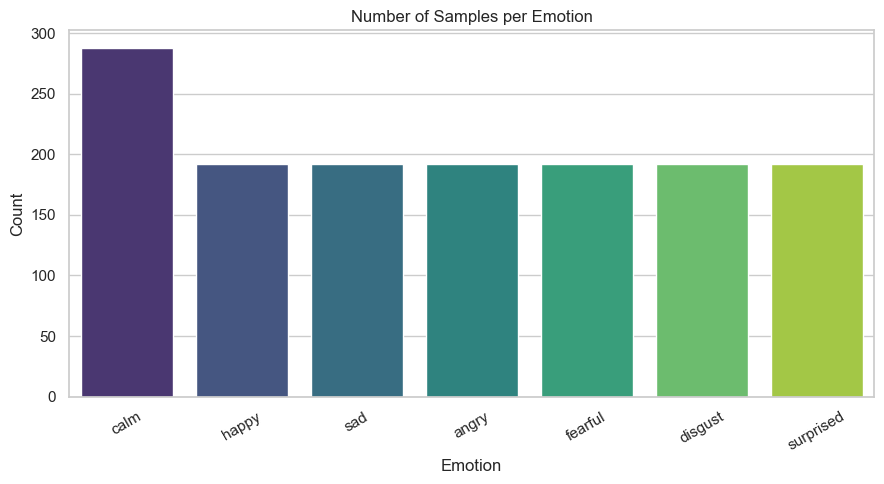

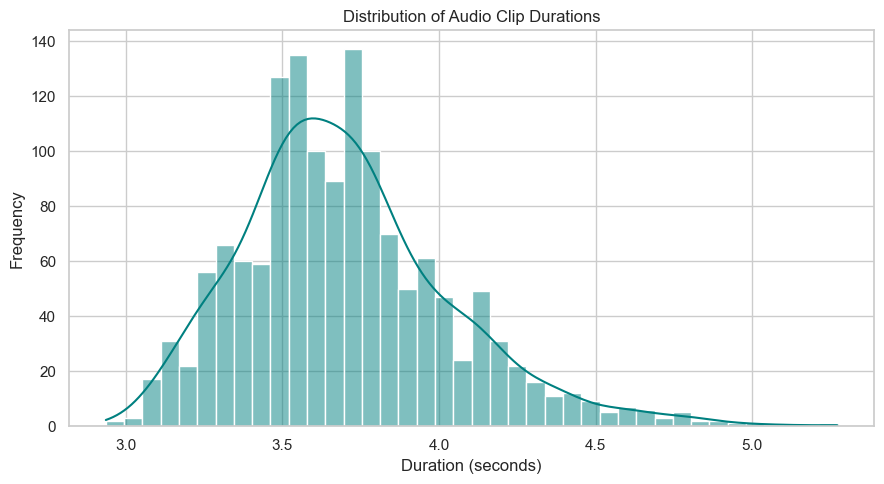

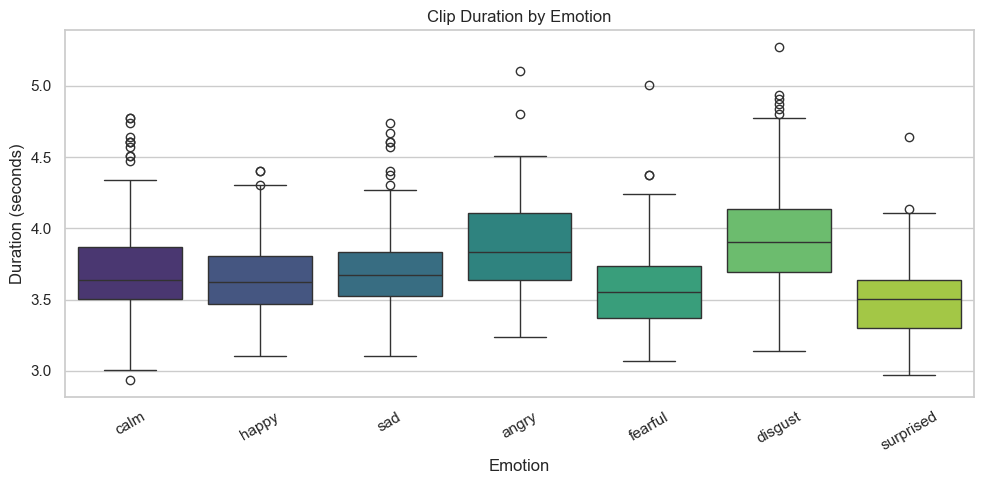

In [8]:
# 3) Dataset-level visualizations (balance, durations)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
emotion_counts = df['emotion'].value_counts().reindex(emotion_order)
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values,
    hue=emotion_counts.index,
    palette="viridis",
    legend=False
)
plt.title('Number of Samples per Emotion')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
savefig('emotion_balance.png')
plt.show()
plt.close()

# Duration distribution + by-emotion boxplot (median included in summary)
plt.figure(figsize=(9,5))
sns.histplot(df['duration'], bins=40, kde=True, color='teal')
plt.title('Distribution of Audio Clip Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.tight_layout()
savefig('duration_hist.png')
plt.show()
plt.close()

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="emotion",
    y="duration",
    hue="emotion",
    order=emotion_order,
    palette="viridis",
    legend=False
)

plt.title("Clip Duration by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Duration (seconds)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("duration_by_emotion.png")
plt.show()
plt.close()

In [9]:
# 4) Pick one representative file per emotion
def get_example_per_emotion(df, actor=1, statement=1):
    examples = {}
    for emotion in emotion_order:
        subset = df[(df['emotion'] == emotion) & (df['actor'] == actor) & (df['statement'] == statement)]
        if len(subset) > 0:
            examples[emotion] = subset.iloc[0]['file_path']
        else:
            fallback = df[df['emotion'] == emotion]
            if len(fallback) > 0:
                examples[emotion] = fallback.iloc[0]['file_path']
    return examples

example_files = get_example_per_emotion(df)
print('Example file per emotion:')
print(example_files)

# Cache decoded audio for example files to avoid multiple loads
example_audio: Dict[str, Tuple[np.ndarray, int]] = {}
for emotion, file_path in example_files.items():
    if file_path and file_path not in example_audio:
        y, sr = librosa.load(file_path, sr=None)
        example_audio[emotion] = (y, sr)

Example file per emotion:
{'calm': '/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav', 'happy': '/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-03-01-01-01-01.wav', 'sad': '/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-04-01-01-01-01.wav', 'angry': '/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-05-01-01-01-01.wav', 'fearful': '/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-06-01-01-01-01.wav', 'disgust': '/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-07-01-01-01-01.wav', 'surprised': '/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-08-01-01-01-01.wav'}


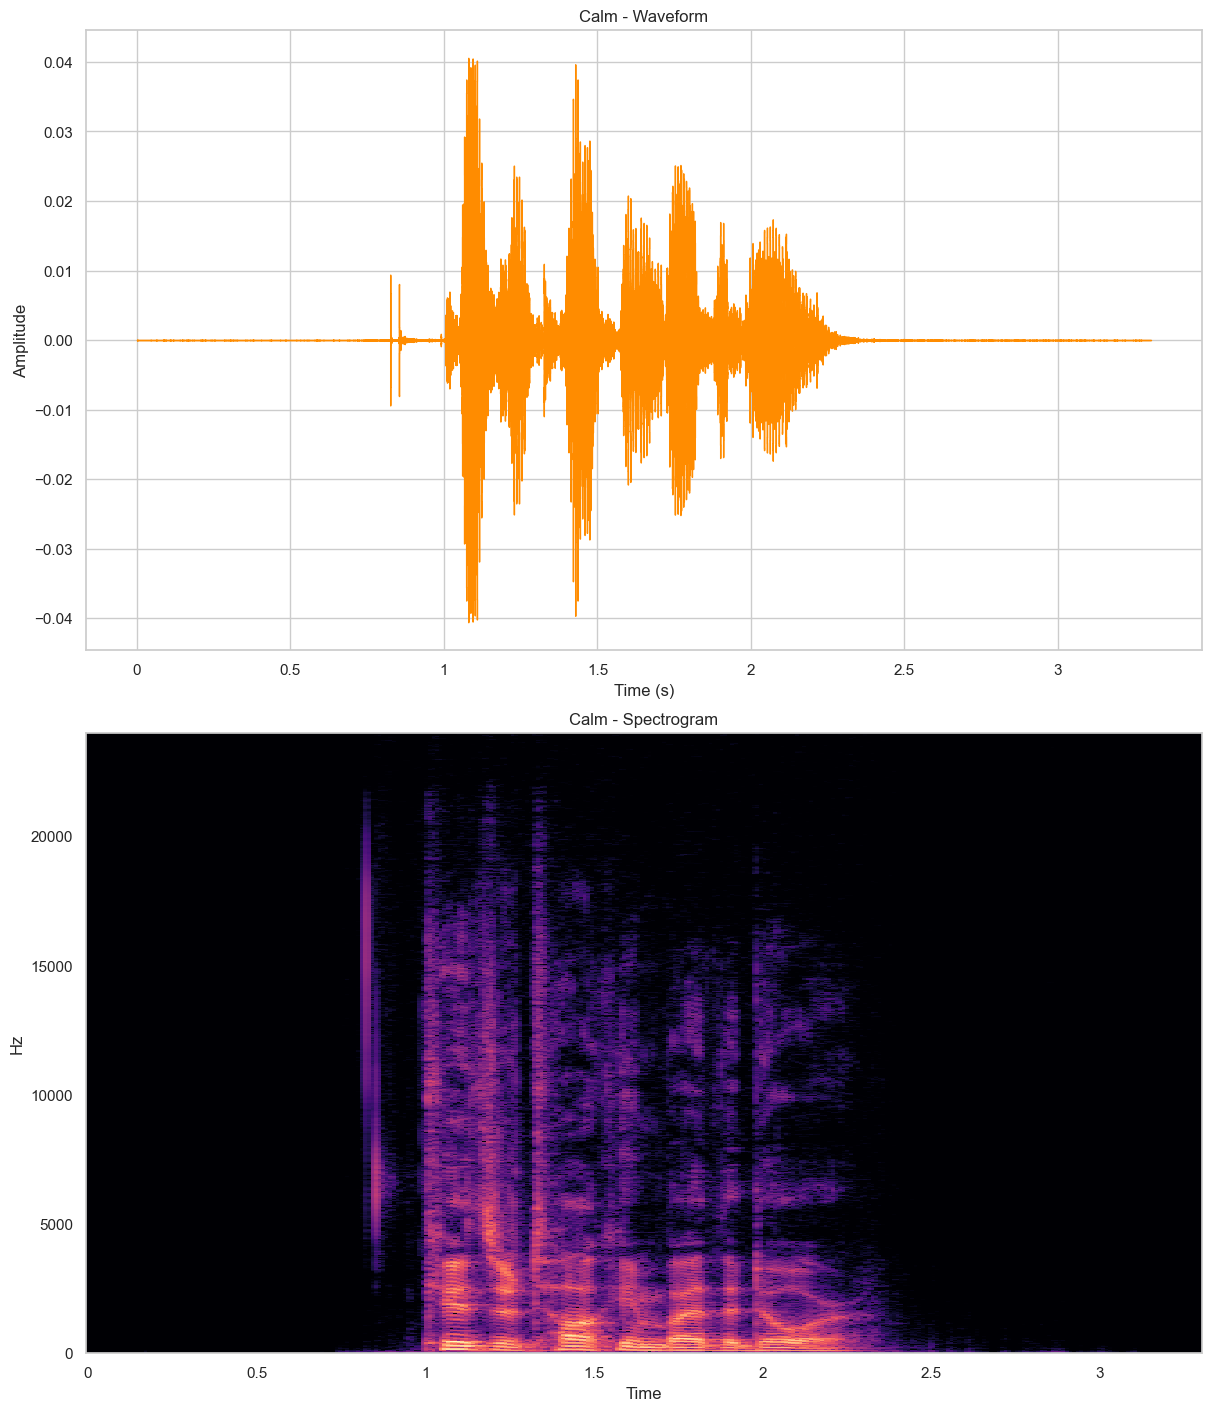

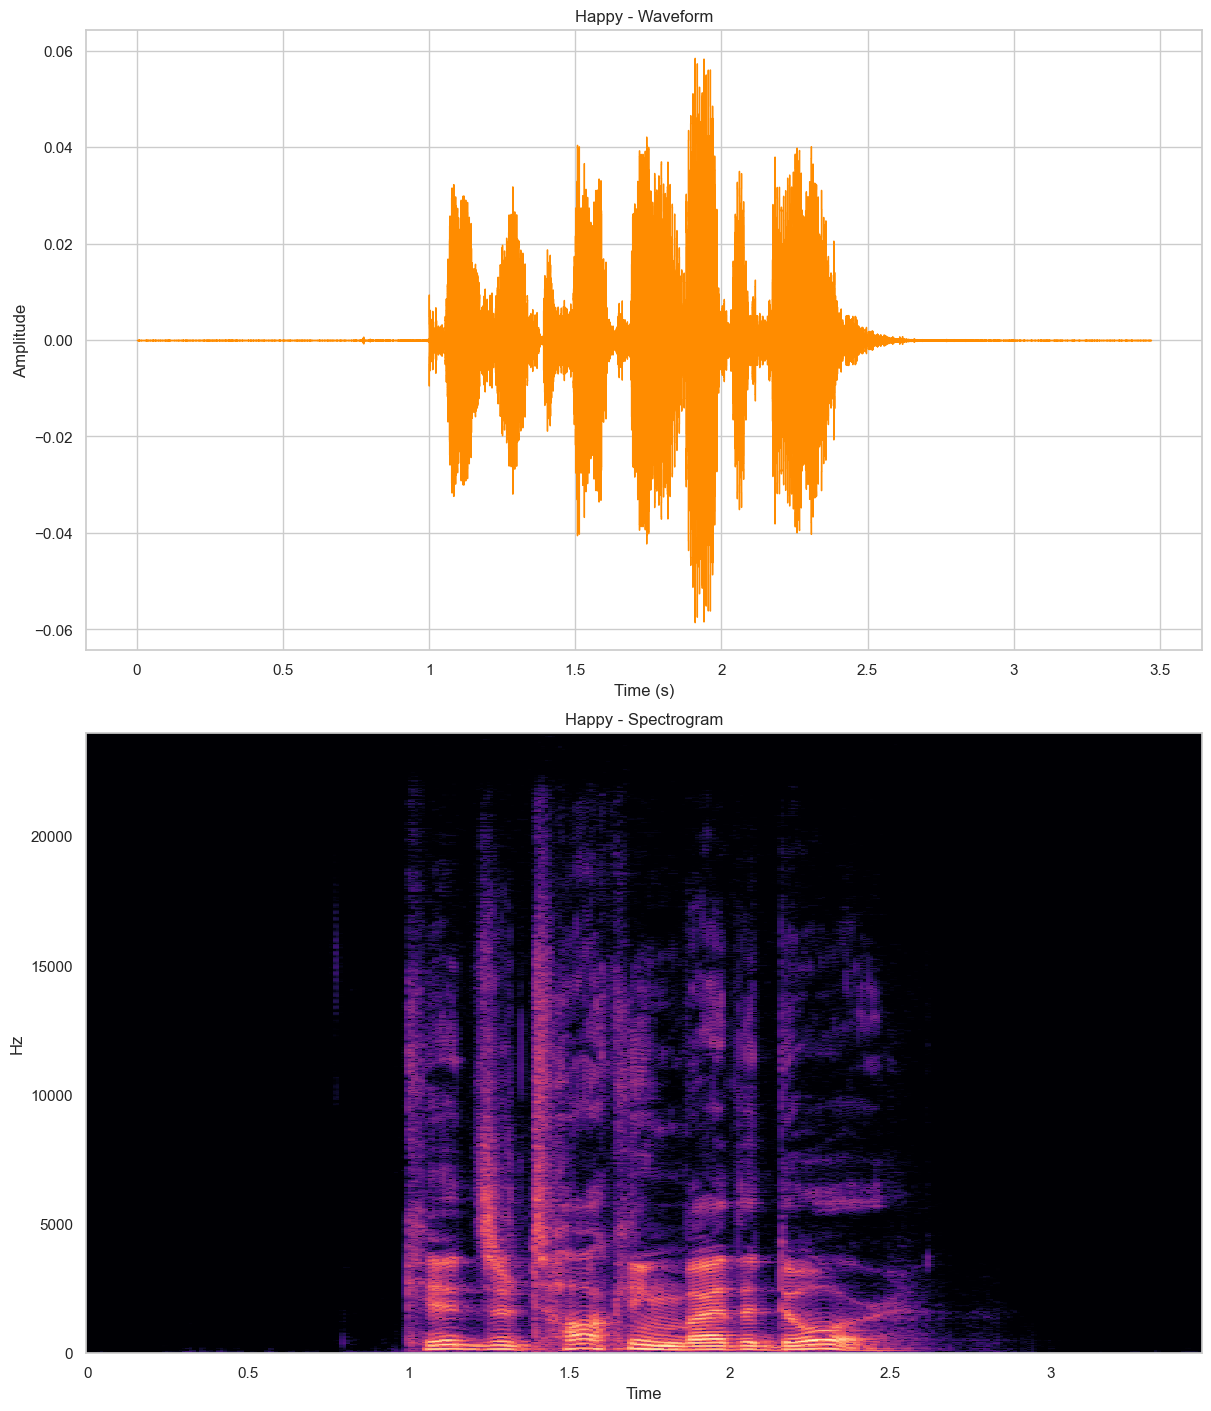

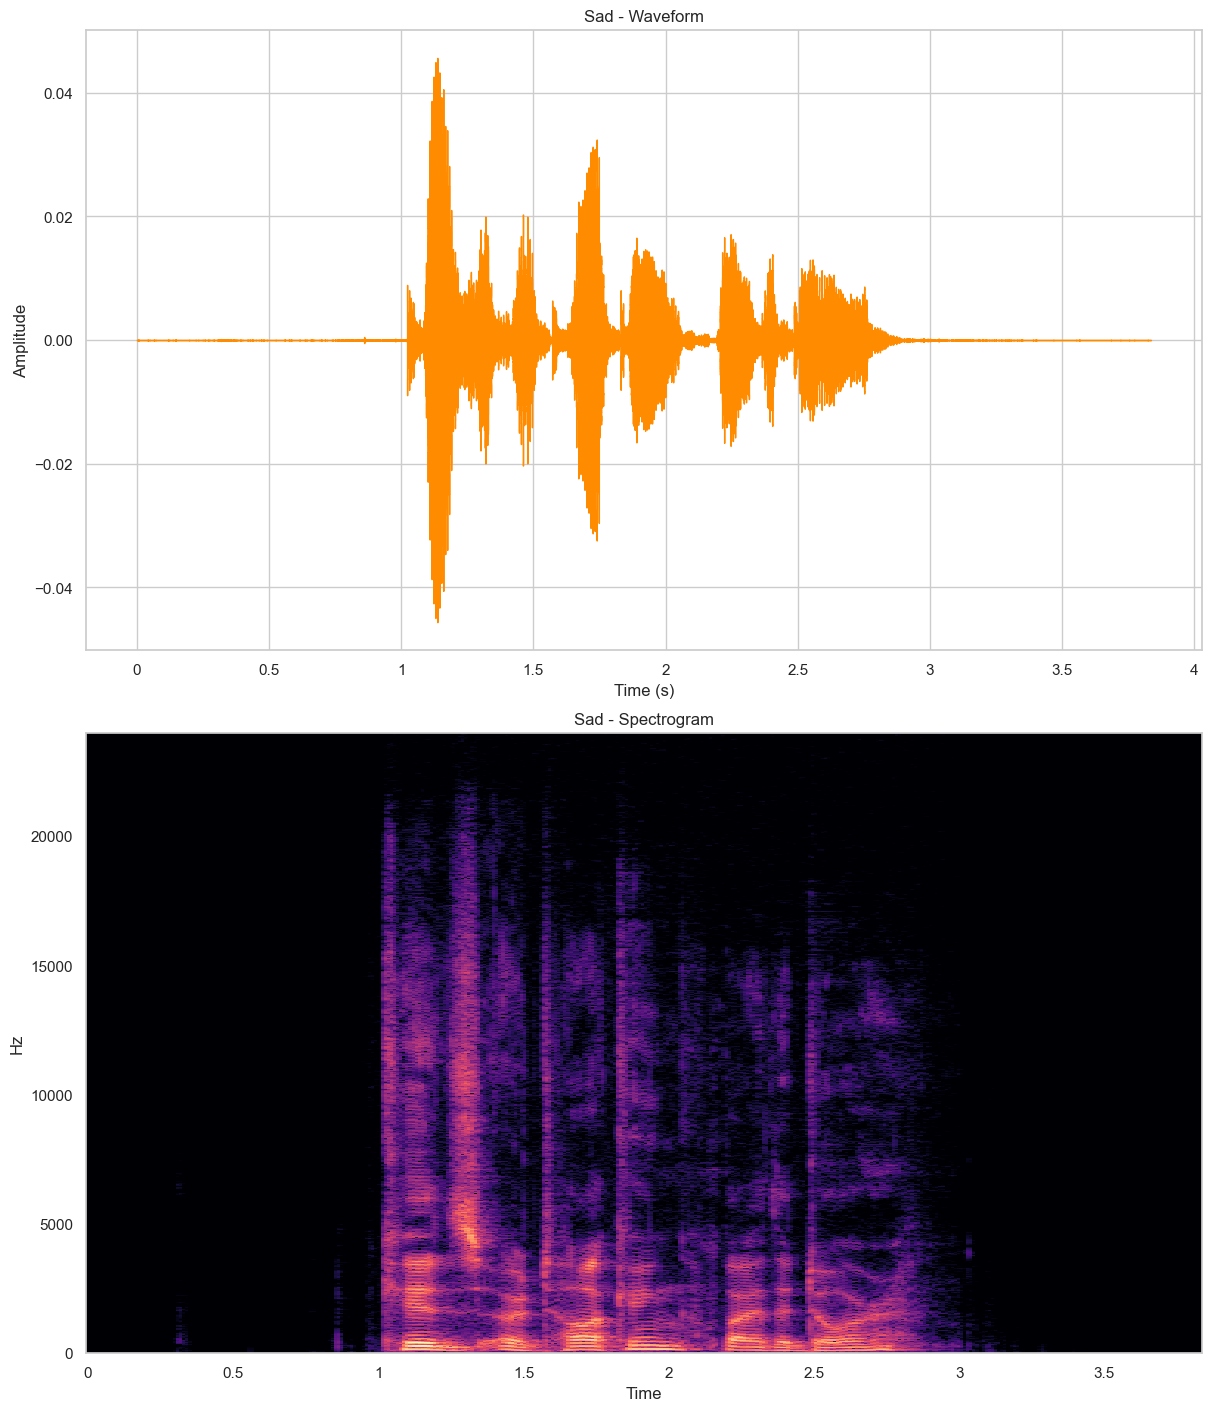

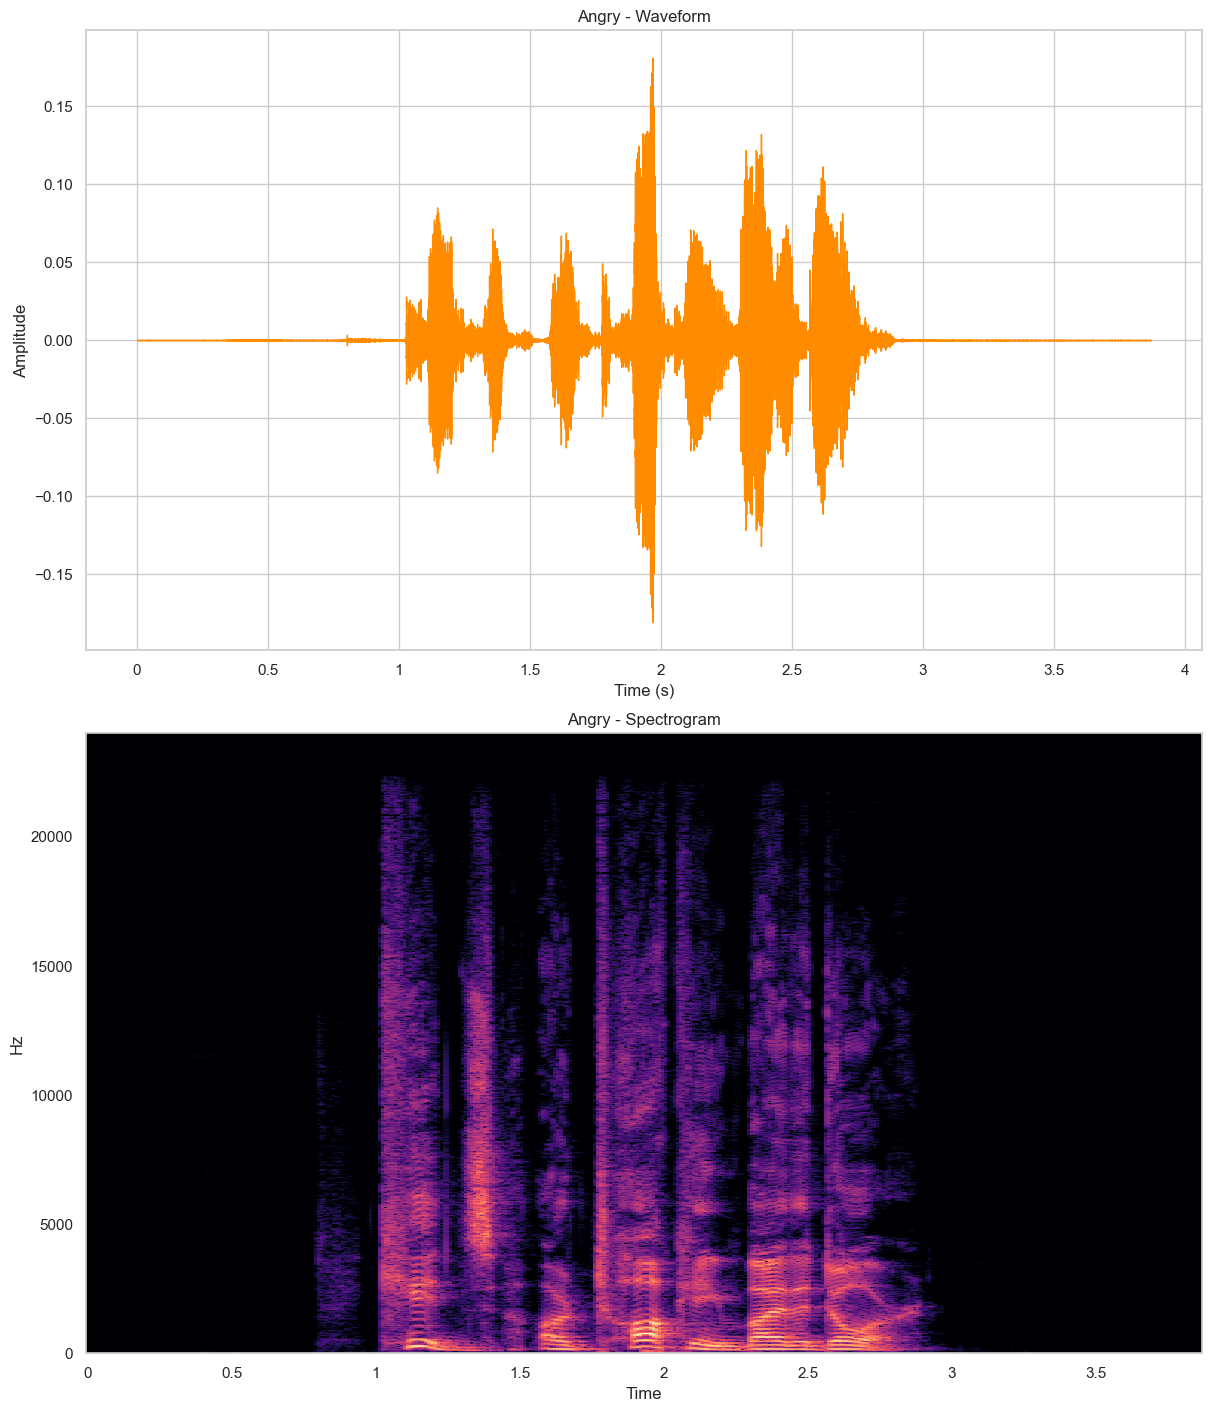

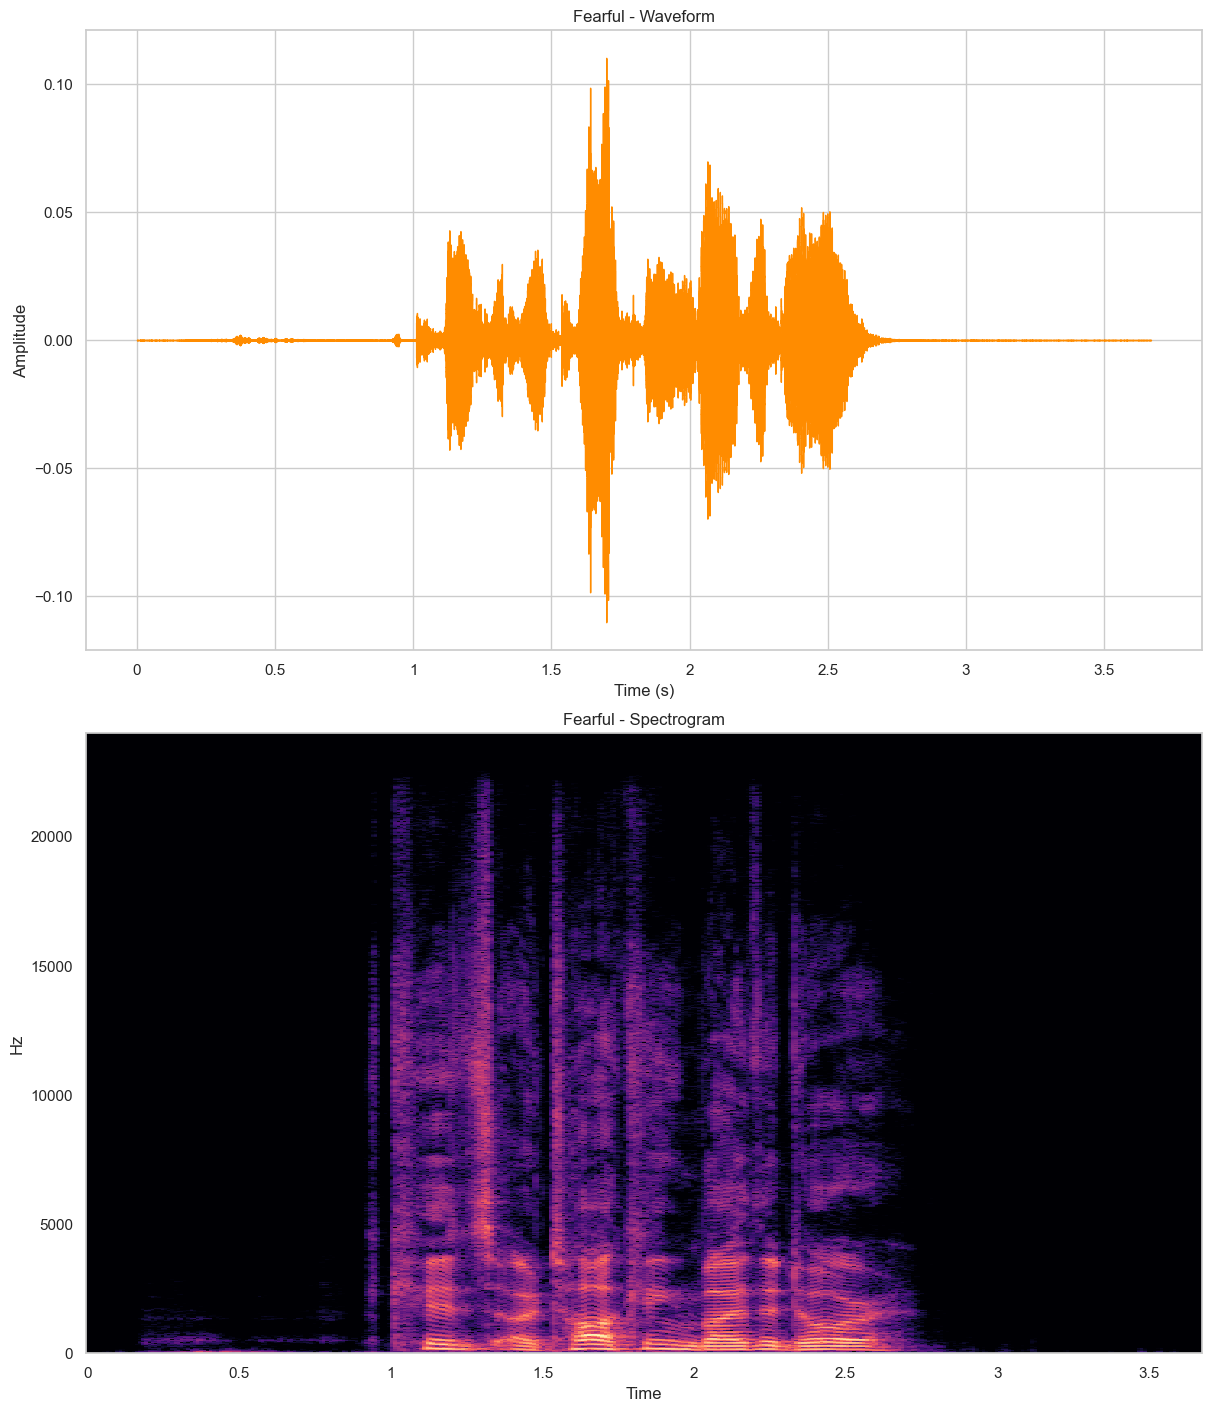

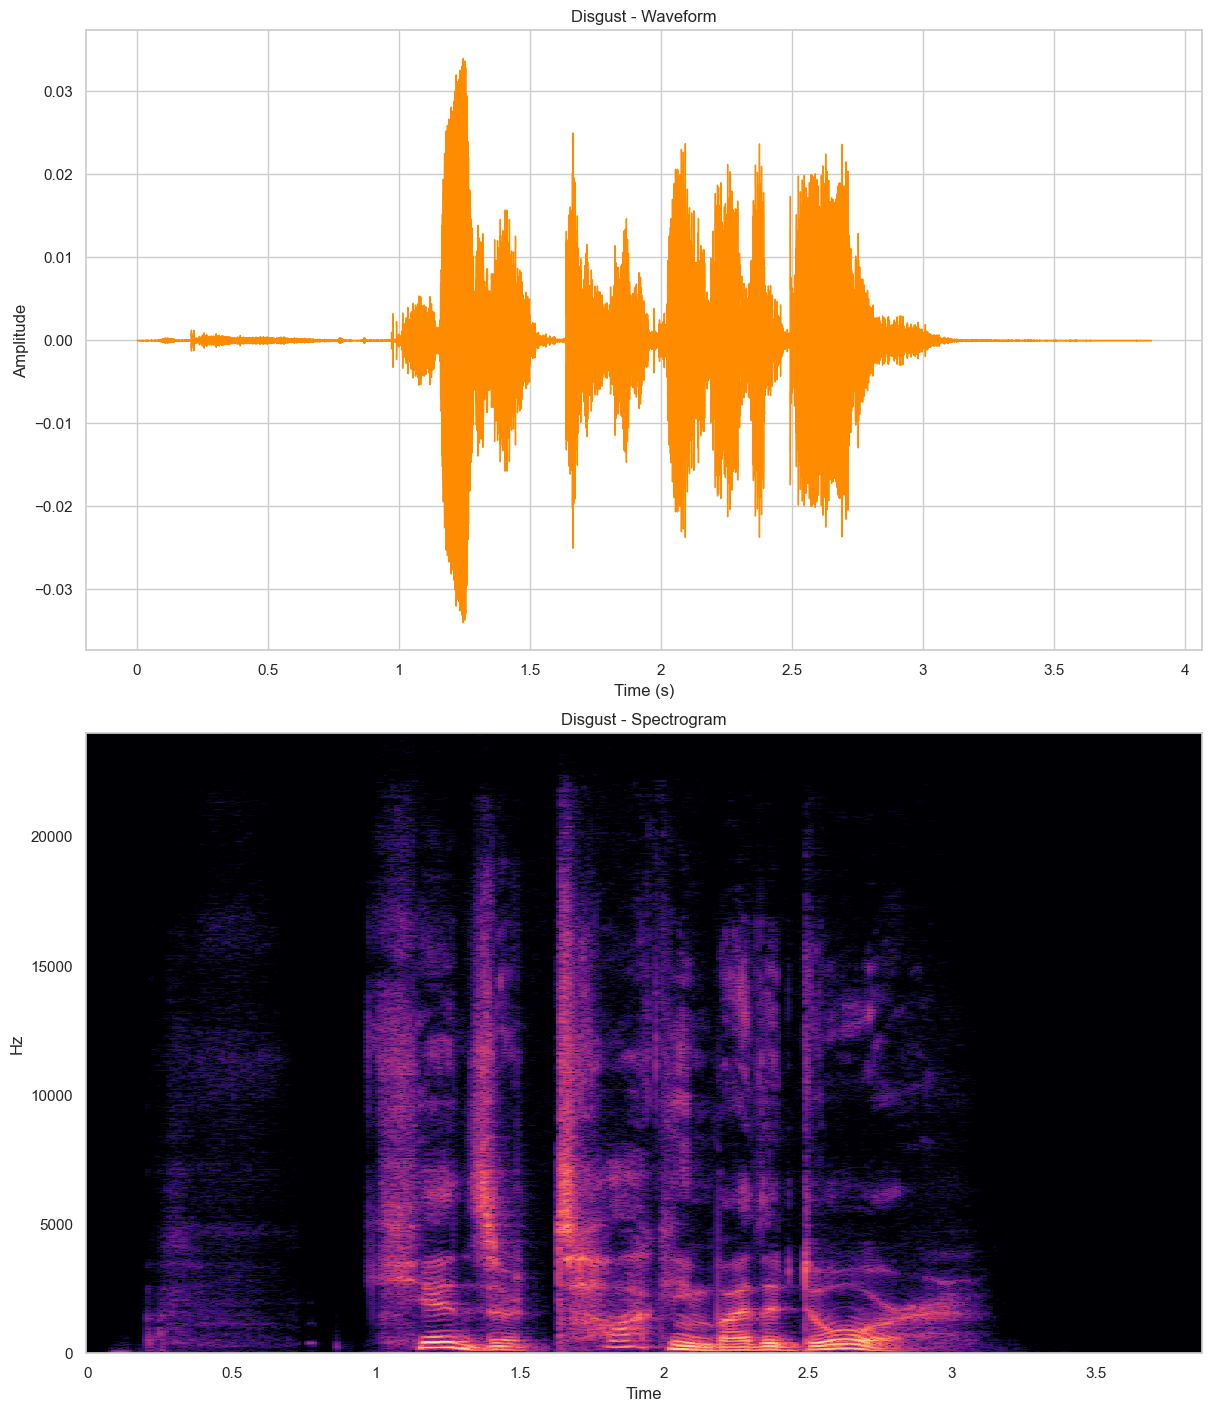

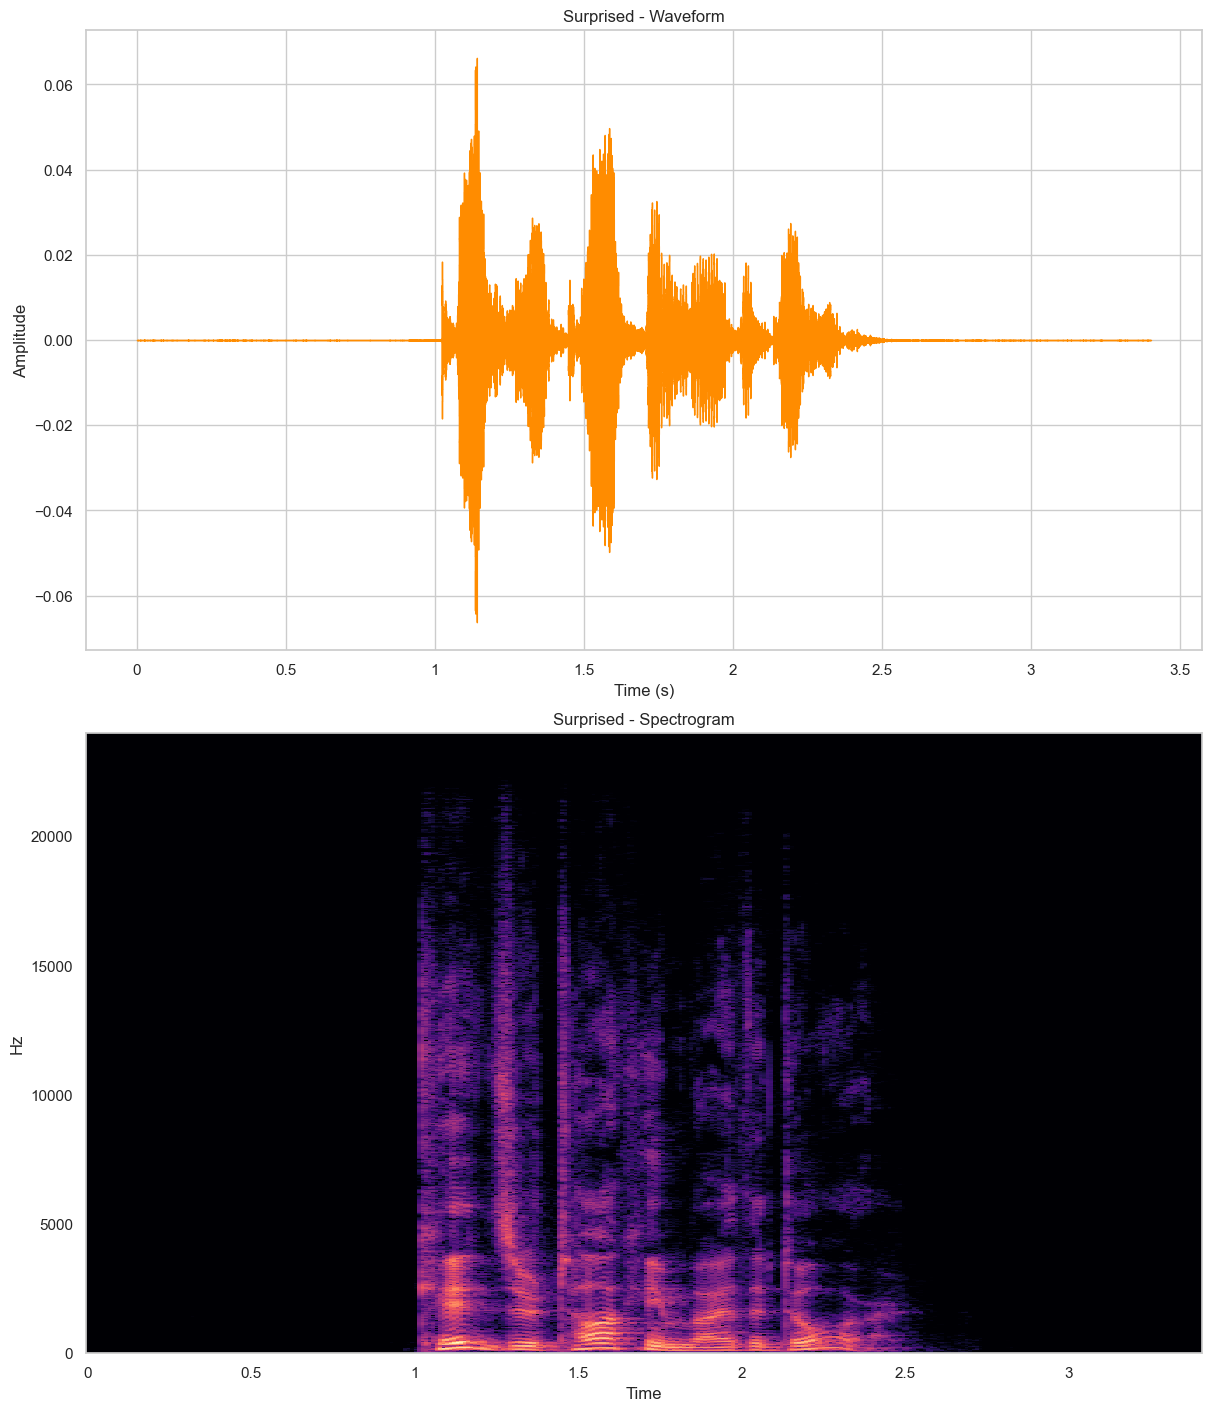

In [10]:
# 5) Combined figure per emotion: Waveform -> Spectrogram -> Mel -> MFCC (use cached example_audio)
for emotion, (y, sr) in example_audio.items():
    fig, axes = plt.subplots(
    2,
    1,
    figsize=(12,14),
    constrained_layout=True
)
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='darkorange')
    axes[0].set_title(f"{emotion.capitalize()} - Waveform")
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')

    # Spectrogram (STFT, dB)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img1 = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='magma')
    axes[1].set_title(f"{emotion.capitalize()} - Spectrogram")


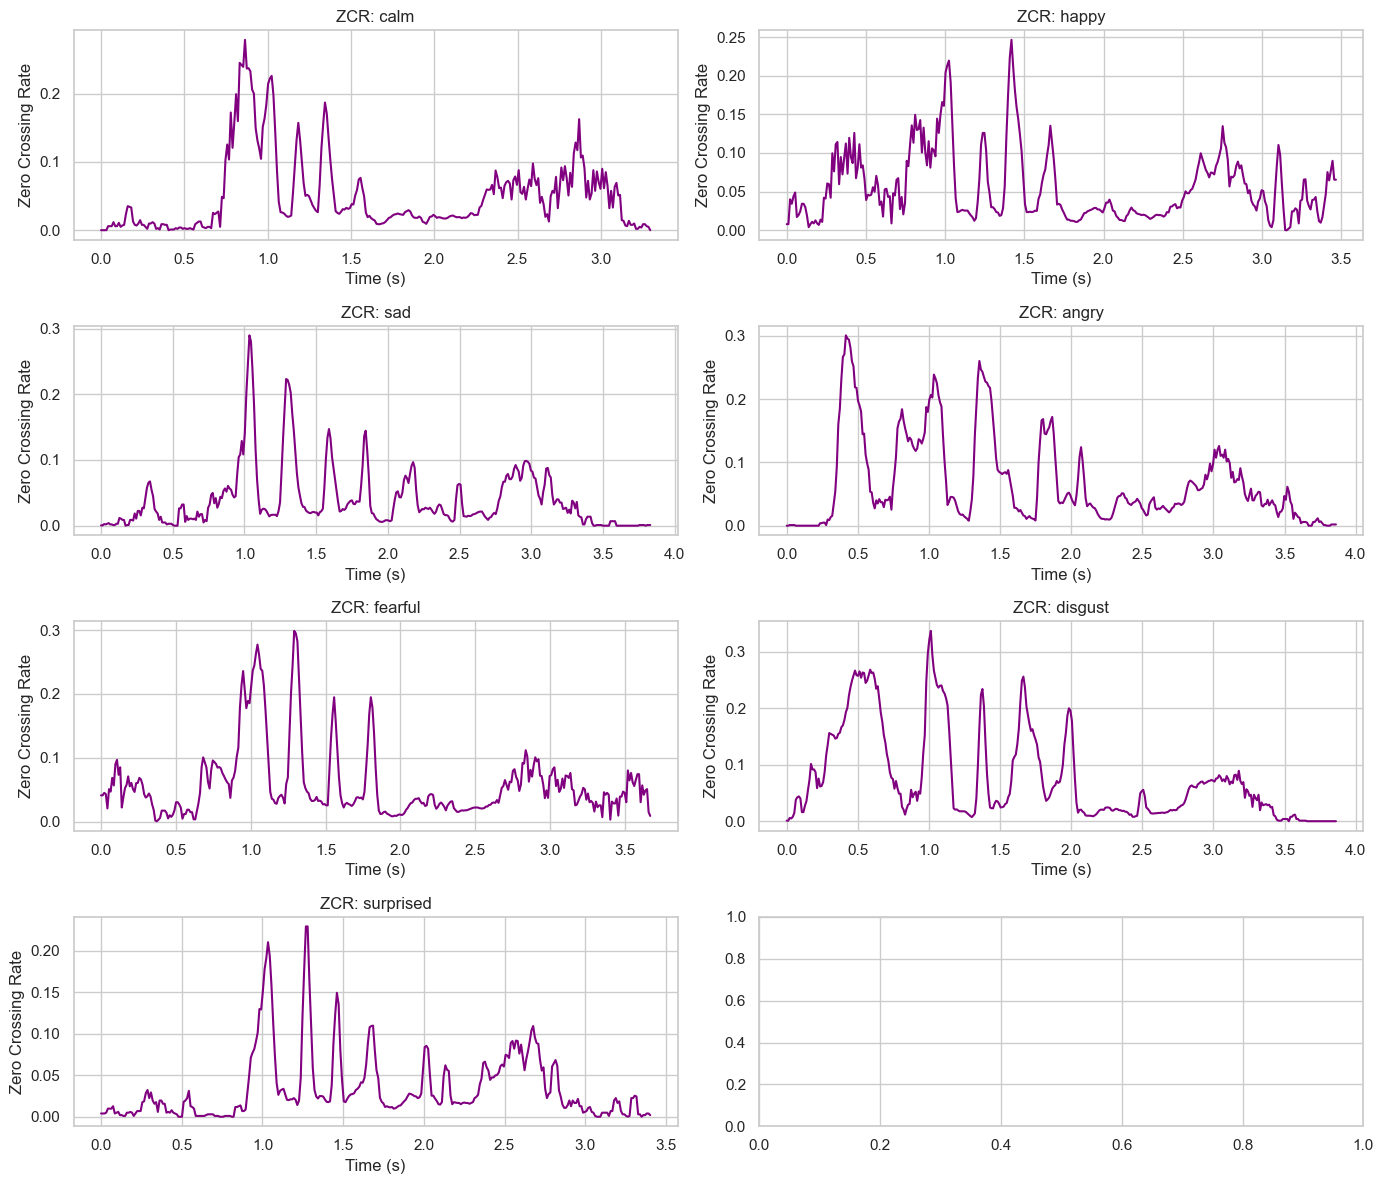

In [11]:
# 6) Zero Crossing Rate (use example_audio cache)
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()
for ax, emotion in zip(axes, emotion_order):
    if emotion not in example_audio:
        ax.set_visible(False)
        continue
    y, sr = example_audio[emotion]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    frames = range(len(zcr))
    t = librosa.frames_to_time(frames, sr=sr)
    ax.plot(t, zcr, color='purple')
    ax.set_title(f"ZCR: {emotion}")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Zero Crossing Rate')
plt.tight_layout()
savefig('zero_crossing_rate.png')
plt.show()
plt.close()

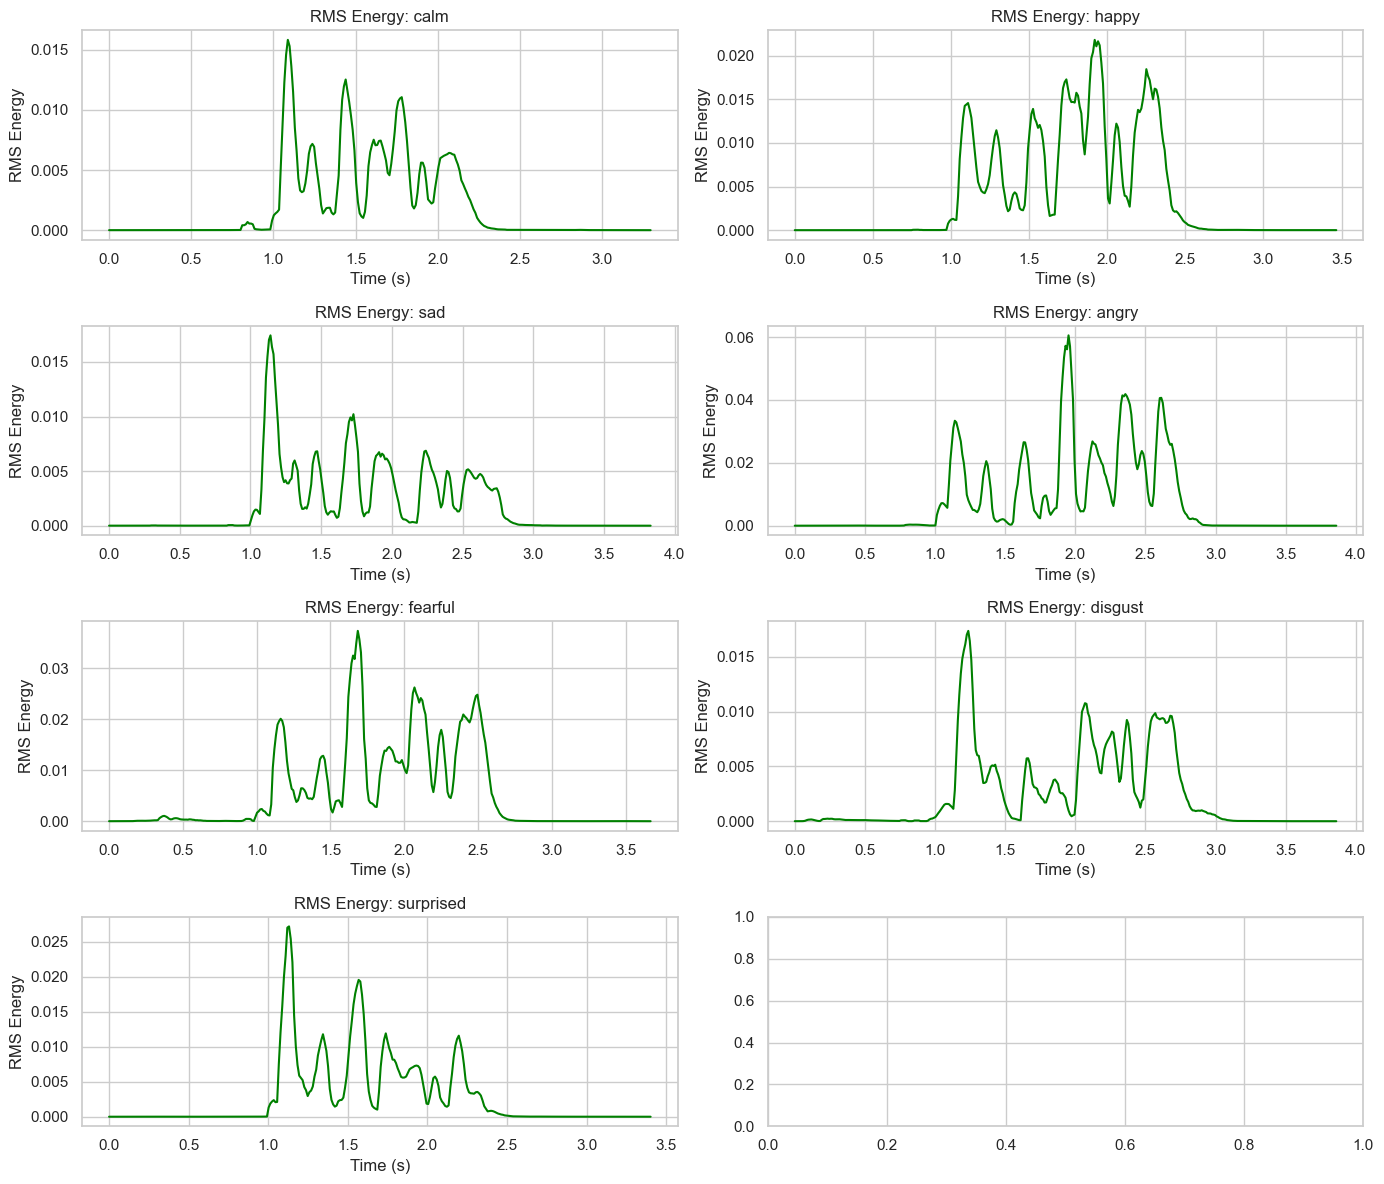

In [12]:
# 7) RMS Energy over time (per-frame) using cached audio
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, emotion in zip(axes, emotion_order):
    if emotion not in example_audio:
        ax.set_visible(False)
        continue

    y, sr = example_audio[emotion]

    rms = librosa.feature.rms(y=y)[0]
    frames = np.arange(len(rms))
    t = librosa.frames_to_time(frames, sr=sr)

    ax.plot(t, rms, color='green')
    ax.set_title(f"RMS Energy: {emotion}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("RMS Energy")

plt.tight_layout()
savefig("rms_energy_over_time.png")
plt.show()
plt.close()

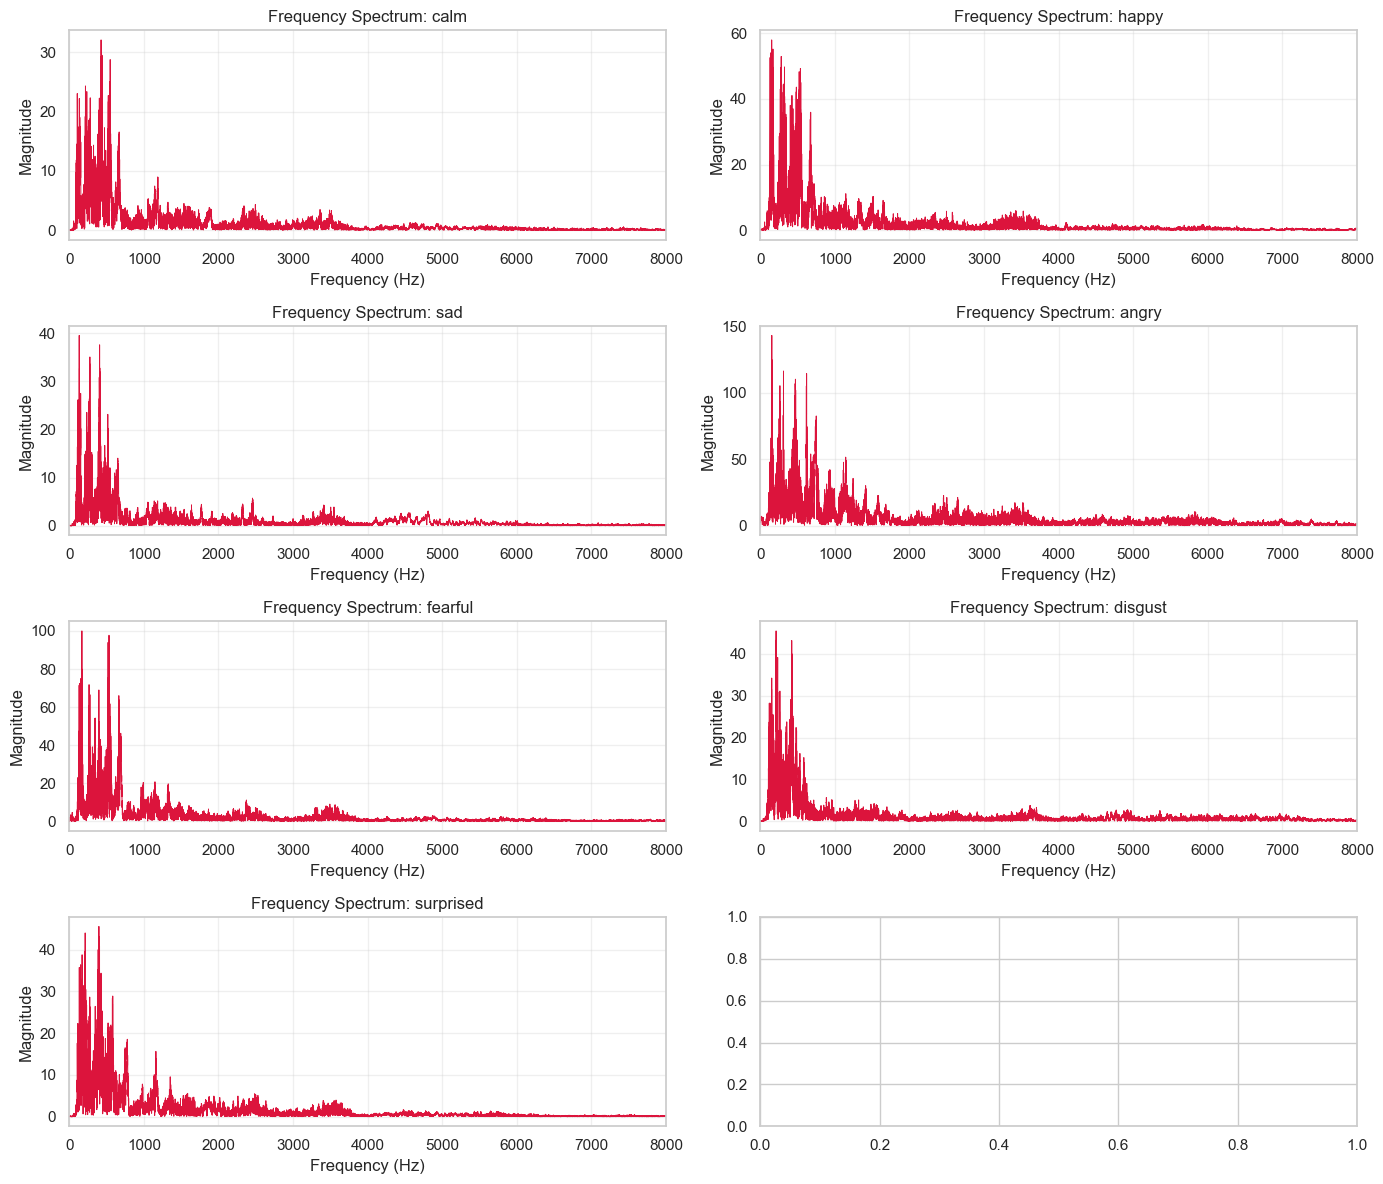

In [13]:
# 8) Frequency Spectrum (FFT) - limit x-axis to 8 kHz (or Nyquist)

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, emotion in zip(axes, emotion_order):
    if emotion not in example_audio:
        ax.set_visible(False)
        continue

    y, sr = example_audio[emotion]

    fft_vals = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), d=1/sr)

    ax.plot(freqs, fft_vals, color="crimson", linewidth=0.7)

    ax.set_title(f"Frequency Spectrum: {emotion}")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")

    ax.set_xlim(0, min(8000, sr / 2))
    ax.grid(alpha=0.3)

plt.tight_layout()
savefig("frequency_spectrum.png")
plt.show()
plt.close()

In [14]:
# 9) Dataset Summary Table

summary = pd.DataFrame({
    "Metric": [
        "Total Files",
        "Actors",
        "Emotion Classes",
        "Mean Duration (s)",
        "Median Duration (s)",
        "Minimum Duration (s)",
        "Maximum Duration (s)",
        "Original Sample Rate(s)",
        "Mean RMS Energy"
    ],
    "Value": [
        len(df),
        df["actor"].nunique(),
        df["emotion"].nunique(),
        round(df["duration"].mean(), 2),
        round(df["duration"].median(), 2),
        round(df["duration"].min(), 2),
        round(df["duration"].max(), 2),
        ", ".join(str(x) for x in sorted(df["sample_rate"].unique())),
        round(df["rms_energy"].mean(), 4)
    ]
})

print("\nDataset Summary\n")
print(summary.to_string(index=False))

summary.to_csv(
    os.path.join(OUTPUT_DIR, "dataset_summary.csv"),
    index=False
)

# Optional:
# summary.to_excel(
#     os.path.join(OUTPUT_DIR, "dataset_summary.xlsx"),
#     index=False
# )


Dataset Summary

                 Metric   Value
            Total Files    1440
                 Actors      24
        Emotion Classes       7
      Mean Duration (s)     3.7
    Median Duration (s)    3.67
   Minimum Duration (s)    2.94
   Maximum Duration (s)    5.27
Original Sample Rate(s) 48000.0
        Mean RMS Energy   0.018


In [15]:
# 10) Save enriched DataFrame for reuse

df.to_csv(
    os.path.join(DATASET_DIR, "ravdess_dataset_with_audio_stats.csv"),
    index=False
)

df.to_pickle(
    os.path.join(DATASET_DIR, "ravdess_dataset_with_audio_stats.pkl")
)

print("\n" + "=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"Total Samples           : {len(df)}")
print(f"Unique Actors           : {df['actor'].nunique()}")
print(f"Emotion Classes         : {df['emotion'].nunique()}")

print(f"Mean Duration           : {df['duration'].mean():.2f} sec")
print(f"Median Duration         : {df['duration'].median():.2f} sec")

print(
    f"Original Sample Rate(s) : "
    f"{', '.join(str(x) for x in sorted(df['sample_rate'].unique()))}"
)

print(f"Figures saved to        : {OUTPUT_DIR}")

print("\nNext Step:")
print("Prepare raw audio (16 kHz mono) for Wav2Vec2 fine-tuning.")

print("=" * 70)


EDA COMPLETED SUCCESSFULLY
Total Samples           : 1440
Unique Actors           : 24
Emotion Classes         : 7
Mean Duration           : 3.70 sec
Median Duration         : 3.67 sec
Original Sample Rate(s) : 48000.0
Figures saved to        : /Users/devanshbansal/Desktop/ser/outputs/analysis

Next Step:
Prepare raw audio (16 kHz mono) for Wav2Vec2 fine-tuning.


# Conclusion

The exploratory data analysis confirms that the RAVDESS dataset is clean,
well-balanced, and suitable for Speech Emotion Recognition using Wav2Vec2.

Key observations:

- No corrupted recordings were detected.
- Audio durations are consistent across emotion classes.
- All recordings share a common original sampling rate.
- Representative waveforms and spectrograms show clear emotional variability.

The enriched 7-class dataset has been saved and is ready for preprocessing into 16 kHz mono waveform inputs for Wav2Vec2 fine-tuning waveforms before Wav2Vec2 fine-tuning.
